# STATISTICAL RISK

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import scipy

In [2]:
#number of days
T = 2000

#expected daily returns
mu = 0.0008


#standard deviation of a risky asset

sigma = 0.02

#VaR based on fixed mu and sigma

alpha = 0.01 #quantile in percentages
VaR = scipy.stats.norm.ppf(alpha, loc=mu, scale=sigma)

print('Fixed 10th percentile value is: '+str(VaR))


Fixed 10th percentile value is: -0.045726957480816816


What it means is that there is a 1 % chance that the loss will be greater than 4.57%.

In [3]:
#time series data over T days

returns = np.random.normal(
    loc=mu,
    scale=sigma,
    size=T
)

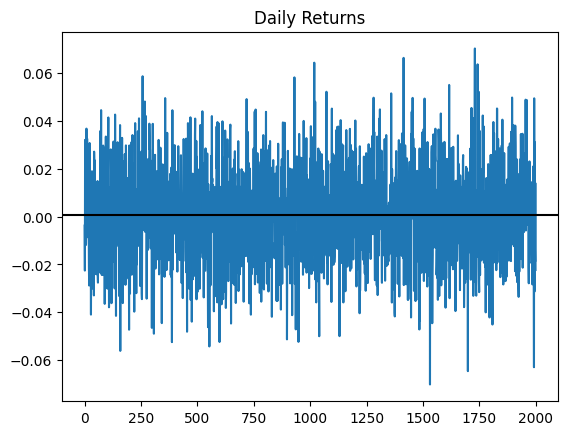

In [4]:
plt.plot(returns)
plt.axhline(y = mu, c='black')
plt.title('Daily Returns')
plt.show()

In [5]:
#compute moving returns and variances
#window 
W = 1000

T_eff = T - W + 1

mu_roll = np.zeros(T_eff)
sigma_roll = np.zeros(T_eff)
VaR_roll = np.zeros(T_eff)
VaR_breach_count = 0

for i in range(0,T_eff):
    window = returns[i:i+W]

    mu_roll[i] = window.mean()
    sigma_roll[i] = window.std()
    VaR_roll[i] = scipy.stats.norm.ppf(alpha, loc=mu_roll[i], scale=sigma_roll[i])

    if returns[i+W-1]<VaR_roll[i]:
        VaR_breach_count = VaR_breach_count + 1



In [6]:
print(len(mu_roll)) # helpful to keep the rolling length in mind

1001


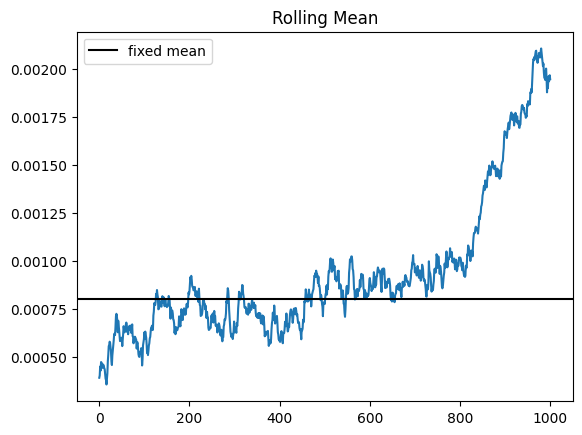

In [7]:
plt.plot(mu_roll)
plt.axhline(y = mu, c='black', label ='fixed mean')
plt.title('Rolling Mean')
plt.legend()
plt.show()

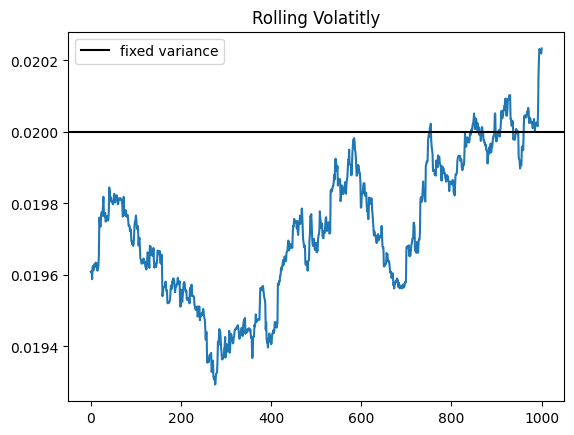

In [8]:
plt.plot(sigma_roll)
plt.axhline(y = sigma, c='black', label ='fixed variance')
plt.title('Rolling Volatitly')
plt.legend()
plt.show()

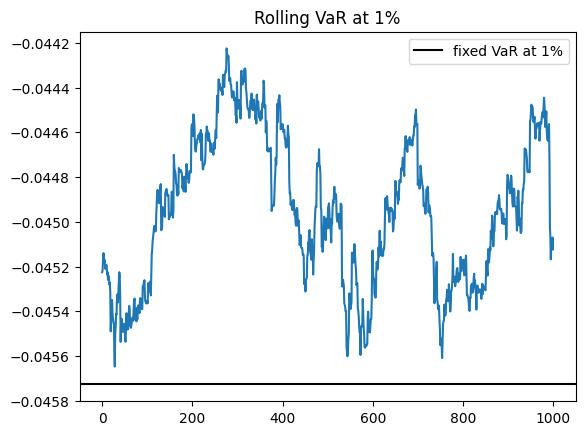

In [9]:
plt.plot(VaR_roll)
plt.axhline(y = VaR, c='black', label ='fixed VaR at 1%')
plt.legend()
plt.title('Rolling VaR at 1%')
plt.show()

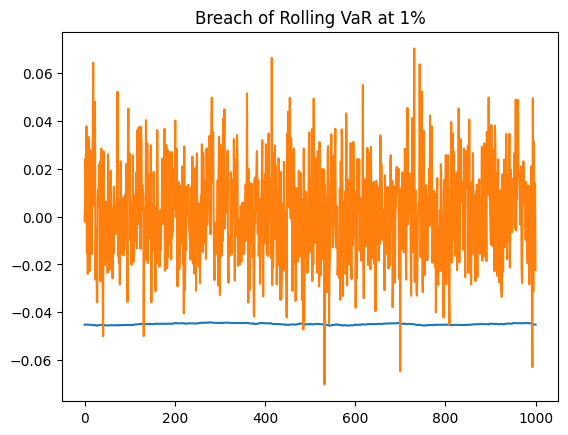

In [10]:
plt.plot(VaR_roll)
plt.plot(returns[999:])
plt.title('Breach of Rolling VaR at 1%')
plt.show()

1% of 1000 is 10. So the breach count is within the statistical ballpark.

In [11]:
VaR_breach_count

6

In [22]:
from matplotlib.animation import FFMpegWriter
from matplotlib.animation import PillowWriter

In [23]:
gaussian = lambda mu, sigma, x: (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-(x-mu)**2./(2*sigma**2))

In [24]:
def make_movie():
    metadata = dict(title='Movie', artist ='ayush_roy')
    writer = FFMpegWriter(fps=10, metadata = metadata)

    # Create the figure and subplots
    fig = plt.figure()

    # First row: Single subplot spanning both columns
    ax = plt.subplot()

    path = 'statistical_risk.mp4'



    with writer.saving(fig, path,100):
        VaR_breach_count = 0
        for i in range(0,T_eff):

            #instantaneous return, rolling return, volatility and VaR at time t
            returns_t = returns[i+W-1]
            mu_t = mu_roll[i]
            sigma_t = sigma_roll[i]
            VaR_t = VaR_roll[i]

            if returns_t<VaR_t:
                VaR_breach_count = VaR_breach_count+1

            if i%1 == 0:
                #plot instantaneous Gaussian
                ax.plot(np.linspace(-0.05,0.05,10000), gaussian(mu_t, sigma_t, np.linspace(-0.5,0.5,10000)), label ='rolling gaussian')

                #plot fixed Gaussian
                ax.plot(np.linspace(-0.05,0.05,10000), gaussian(mu, sigma, np.linspace(-0.5,0.5,10000)), linestyle='dashed', label ='fixed gaussian')

                #instantaneous return
                ax.axvline(x=returns_t, c='black', linestyle='dashed', label='inst. returns')

                #instantaneous VaR
                ax.axvline(x=VaR_t, c='red', linestyle='dashed', label ='rolling VaR')


              
                ax.set_title('t: '+str(i + W))
                ax.legend(loc=1)
                ax.set_xlabel(r'$Return$')
                ax.set_ylabel(r'$Probability Density$')
                ax.set_xlim([-0.07, 0.07])
                ax.set_ylim([-0.1, 21])
                ax.text( -0.06,15, 'VaR breach: '+str(VaR_breach_count))
                writer.grab_frame()
                ax.cla()

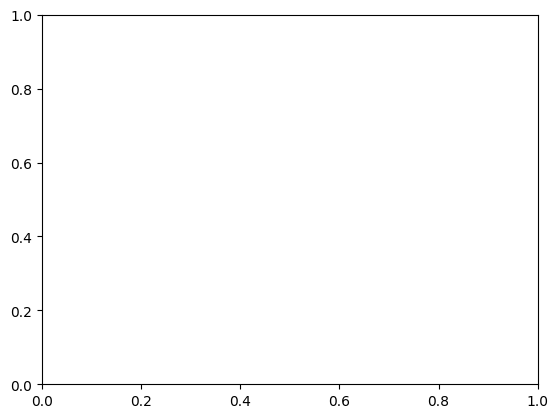

In [25]:
make_movie()